# Quantum Machine Learning: where is the advantage?

### Classical vs hybrid vs quantum algorithms -- a hands-on comparison

This notebook sits next to the Amplitude Estimation / VaR / credit-risk series,
but switches topic to **learning from data**. The goal is didactic and honest:

- what people *mean* by Quantum Machine Learning (QML);
- which advantages are **theoretical**, which are **practical today**;
- how **classical**, **hybrid** (variational), and **quantum** (kernel / linear-algebra)
  approaches differ -- with runnable toy experiments and charts.

**One-sentence preview**

> Classical ML is mature and hard to beat on small/medium data; hybrid QML trains
> a parameterized circuit with a classical optimizer (NISQ-friendly, but noisy and
> often no proven speedup); "full" quantum ML promises asymptotic gains on kernels
> and linear algebra -- *if* data loading and error correction cooperate.

**Roadmap**

1. Three families of algorithms (classical / hybrid / quantum)
2. Where a quantum advantage *could* come from
3. A fair comparison table (complexity, hardware, maturity)
4. Toy dataset: nonlinear classification
5. Classical baseline (logistic + RBF SVM)
6. Quantum-inspired feature map / kernel (ZZ-style, numpy mimic)
7. The real feature map: Qiskit `ZZFeatureMap` and the exact fidelity kernel
8. Bandwidth: the hyperparameter that decides the whole story
9. The bill nobody prints: shot noise and pair counting
10. Hybrid flavour: variational circuit as a model
11. The toy VQC is a linear model in disguise -- and an entangling repair
12. Scaling charts: sample complexity and kernel cost sketches
13. Caveats: barren plateaus (measured, not drawn), data loading, noise
14. Scoreboard over repeated splits + takeaways for a thesis narrative

> Related repo material: `../tesi/papers/L0_fondamenta/L0_05_rebentrost_qml_2014.py`,
> `../tesi/papers/L2C_qml/`, surveys in L1.


## 0. Setup

In [1]:
import sys

try:
    sys.stdout.reconfigure(encoding='utf-8')
except (AttributeError, ValueError):
    pass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.28,
    'font.size': 11,
    'axes.titlesize': 13,
})

from time import perf_counter

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

try:  # Qiskit >= 1.3 exposes the builder function; older versions the class
    from qiskit.circuit.library import zz_feature_map
except ImportError:  # pragma: no cover
    from qiskit.circuit.library import ZZFeatureMap as _ZZ

    def zz_feature_map(feature_dimension, reps=2, entanglement='linear'):
        return _ZZ(feature_dimension=feature_dimension, reps=reps,
                   entanglement=entanglement)

import qiskit

rng = np.random.default_rng(42)
print(f'numpy {np.__version__} | qiskit {qiskit.__version__} - ready')


numpy 2.5.0 | qiskit 2.5.0 - ready


## 1. Three families -- do not mix them up

In papers and bank decks, "QML" often lumps three different things together.

| Family | What runs where | Typical algorithms | Reality check |
|--------|-----------------|--------------------|---------------|
| **Classical ML** | CPU/GPU only | logistic regression, random forests, deep nets, SVM | Production standard |
| **Hybrid QML** | quantum circuit *plus* classical optimizer | VQC / QNN, QAOA-inspired classifiers, variational kernels | Runs on NISQ; advantage unproven |
| **Quantum ML** (algorithmic) | quantum subroutines with proven or conjectured speedups | quantum kernels with QKE, HHL-style linear systems, quantum PCA, Grover-type search | Needs better hardware / loading |

```text
CLASSICAL                 HYBRID                      QUANTUM (algorithmic)
---------                 ------                      --------------------
data -> model -> pred     data -> encode -> U(theta)  data -> oracles / QRAM
                          |              |            |
                          +-- classical -+            +-- BQP-style routines
                              optimizer                   (kernels, HHL, ...)
```

For a thesis, being precise about *which* family you discuss is already a contribution.


## 2. Where could a quantum advantage come from?

Four recurring arguments (keep them separate):

1. **Hilbert-space features.** A shallow circuit can embed data into a very high-
   dimensional feature space. Overlap of quantum states defines a **kernel** that
   may be hard to simulate classically for some feature maps.
2. **Linear algebra.** HHL-type algorithms solve $Ax=b$ with complexity depending
   on condition number and sparsity -- potentially exponentially smaller *query*
   complexity than classical, under strong assumptions (including data access).
3. **Sampling / estimation.** Amplitude Estimation (the VaR notebooks!) can turn
   expectation-value estimation from $O(1/\varepsilon^2)$ into $O(1/\varepsilon)$.
4. **Optimization landscape.** Sometimes a quantum ansatz explores a different
   hypothesis class -- but variational training can also get stuck (barren plateaus).

None of these is free. Data loading (QRAM / state preparation), noise, and the
existence of strong classical baselines often erase the asymptotic story on real data.


## 3. Comparison at a glance


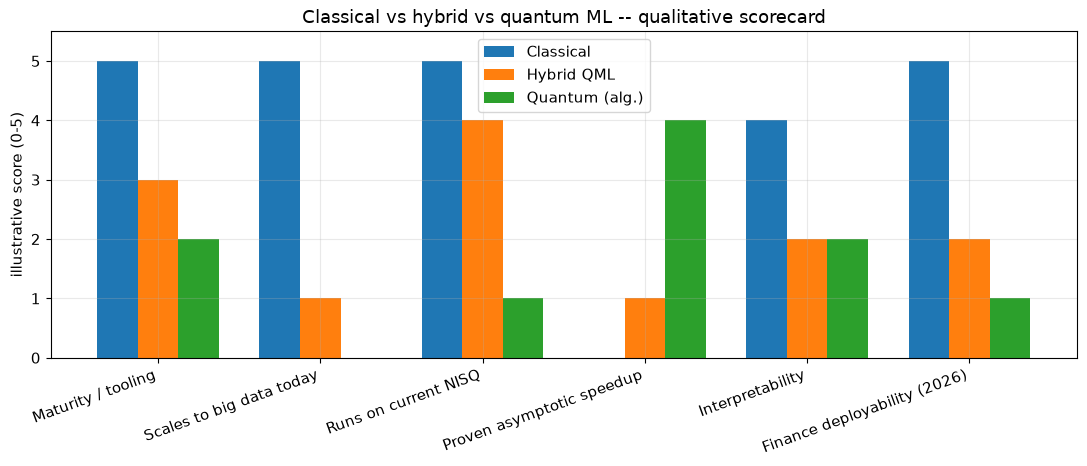

Read this as a map of trade-offs, not as a ranking of "better".


In [2]:
# Visual scorecard (subjective but useful for discussion)
criteria = [
    'Maturity / tooling',
    'Scales to big data today',
    'Runs on current NISQ',
    'Proven asymptotic speedup',
    'Interpretability',
    'Finance deployability (2026)',
]
# scores 0-5 (illustrative, not a benchmark)
scores = {
    'Classical': [5, 5, 5, 0, 4, 5],
    'Hybrid QML': [3, 1, 4, 1, 2, 2],
    'Quantum (alg.)': [2, 0, 1, 4, 2, 1],
}

x = np.arange(len(criteria))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 4.8))
for i, (name, vals) in enumerate(scores.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(criteria, rotation=20, ha='right')
ax.set_ylim(0, 5.5)
ax.set_ylabel('illustrative score (0-5)')
ax.set_title('Classical vs hybrid vs quantum ML -- qualitative scorecard')
ax.legend()
plt.tight_layout()
plt.show()

print('Read this as a map of trade-offs, not as a ranking of "better".')


### How to read the scorecard

- **Classical** wins on maturity and deployability -- that is why banks still ship
  gradient-boosted trees for credit scoring.
- **Hybrid** is what you can actually run on today's hardware: nice for demos and
  research, weak on proven speedups.
- **Algorithmic quantum** scores high on *potential* complexity gains, low on
  "does it run on my laptop / a 2026 QPU for real portfolios?".


## 4. Toy dataset: a nonlinear classification problem

We build a 2D "two moons"-like problem where a linear classifier fails,
so that kernels / feature maps have something useful to do.


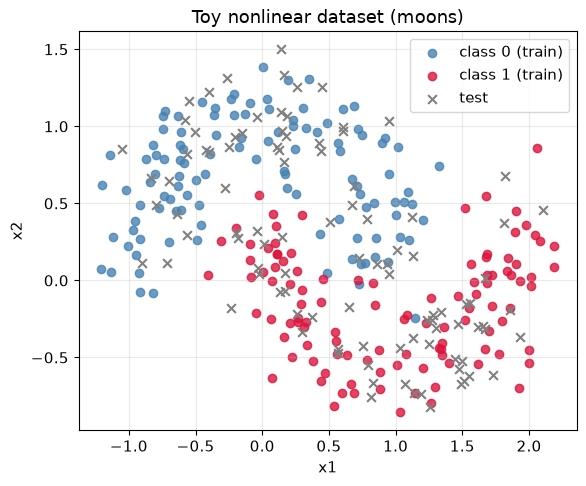

train=220, test=100


In [3]:
def make_moons(n=300, noise=0.18, seed=42):
    r = np.random.default_rng(seed)
    n2 = n // 2
    theta = r.uniform(0, np.pi, n2)
    x0 = np.column_stack([np.cos(theta), np.sin(theta)])
    x1 = np.column_stack([1 - np.cos(theta), 0.5 - np.sin(theta)])
    X = np.vstack([x0, x1]) + r.normal(0, noise, (n, 2))
    y = np.array([0] * n2 + [1] * n2)
    # shuffle
    perm = r.permutation(n)
    return X[perm], y[perm]


X, y = make_moons(n=320, noise=0.20)
# train / test split
n_train = 220
X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test = X[n_train:], y[n_train:]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='steelblue',
           label='class 0 (train)', alpha=0.8)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='crimson',
           label='class 1 (train)', alpha=0.8)
ax.scatter(X_test[:, 0], X_test[:, 1], c='gray', marker='x', s=40, label='test')
ax.set_title('Toy nonlinear dataset (moons)')
ax.legend()
ax.set_xlabel('x1')
ax.set_ylabel('x2')
plt.tight_layout()
plt.show()
print(f'train={len(y_train)}, test={len(y_test)}')


## 5. Classical baselines: logistic regression vs RBF SVM (kernel)

We implement two classical models from scratch / with numpy only:

- **Logistic regression** on raw features (linear decision boundary).
- **Kernel SVM (soft-margin hinge, simplified)** via an RBF Gram matrix --
  the classical champion for small nonlinear problems.

Accuracy on the test set is our yardstick for the next sections.


In [4]:
def standardize(X_tr, X_te):
    mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-12
    return (X_tr - mu) / sd, (X_te - mu) / sd, mu, sd


Xs_train, Xs_test, mu, sd = standardize(X_train, X_test)


def fit_logistic(X, y, lr=0.3, steps=800, l2=1e-2):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    yt = 2 * y - 1  # +/-1
    hist = []
    for _ in range(steps):
        z = X @ w + b
        # logistic loss gradient
        p = 1 / (1 + np.exp(-z))
        err = p - y
        w -= lr * (X.T @ err / n + l2 * w)
        b -= lr * err.mean()
        pred = (z > 0).astype(int)
        hist.append((pred == y).mean())
    return w, b, np.array(hist)


def predict_logistic(X, w, b):
    return (X @ w + b > 0).astype(int)


w_log, b_log, hist_log = fit_logistic(Xs_train, y_train)
acc_log_tr = (predict_logistic(Xs_train, w_log, b_log) == y_train).mean()
acc_log_te = (predict_logistic(Xs_test, w_log, b_log) == y_test).mean()
print(f'Logistic  train={acc_log_tr:.3f}  test={acc_log_te:.3f}')


def rbf_kernel(A, B, gamma=1.5):
    # k(x,y) = exp(-gamma ||x-y||^2)
    aa = np.sum(A * A, axis=1)[:, None]
    bb = np.sum(B * B, axis=1)[None, :]
    dist2 = aa + bb - 2 * A @ B.T
    return np.exp(-gamma * np.clip(dist2, 0, None))


def fit_kernel_ridge_classifier(X, y, gamma=1.5, lam=1e-2):
    # Simple, stable classical kernel method: kernel ridge on +/-1 labels
    K = rbf_kernel(X, X, gamma=gamma)
    yt = 2 * y - 1.0
    alpha = np.linalg.solve(K + lam * np.eye(len(y)), yt)
    return alpha, gamma, lam


def predict_kernel_ridge(X_tr, X_new, alpha, gamma):
    K = rbf_kernel(X_new, X_tr, gamma=gamma)
    scores = K @ alpha
    return (scores > 0).astype(int), scores


alpha_rbf, gamma_rbf, _ = fit_kernel_ridge_classifier(Xs_train, y_train)
pred_rbf_tr, _ = predict_kernel_ridge(Xs_train, Xs_train, alpha_rbf, gamma_rbf)
pred_rbf_te, _ = predict_kernel_ridge(Xs_train, Xs_test, alpha_rbf, gamma_rbf)
acc_rbf_tr = (pred_rbf_tr == y_train).mean()
acc_rbf_te = (pred_rbf_te == y_test).mean()
print(f'RBF kernel ridge  train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')


Logistic  train=0.873  test=0.860
RBF kernel ridge  train=0.986  test=0.990


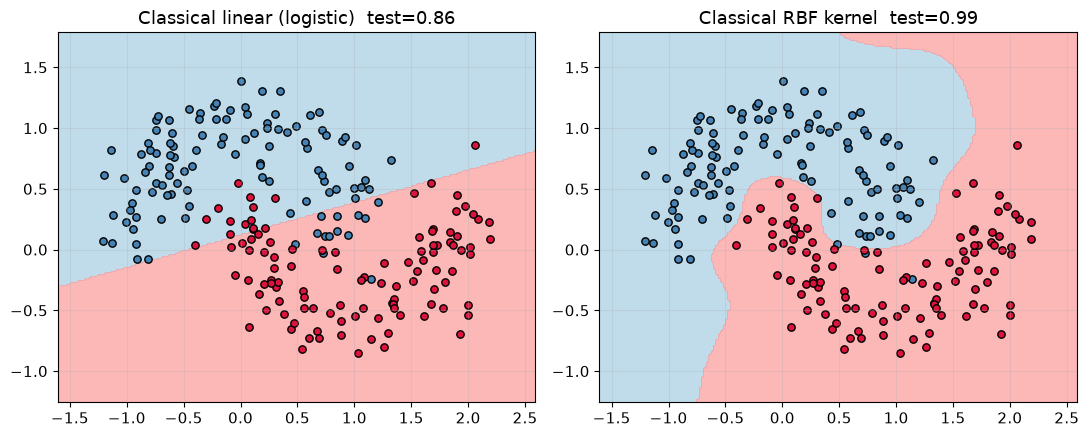

In [5]:
def plot_decision(ax, predict_fn, X, y, title, res=200):
    xmin, xmax = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    ymin, ymax = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, res),
                         np.linspace(ymin, ymax, res))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = predict_fn(grid).reshape(xx.shape)
    cmap = ListedColormap(['#a6cee3', '#fb9a99'])
    ax.contourf(xx, yy, zz, levels=[-0.1, 0.5, 1.1], cmap=cmap, alpha=0.7)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='steelblue', edgecolor='k', s=28)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='crimson', edgecolor='k', s=28)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision(
    axes[0],
    lambda G: predict_logistic((G - mu) / sd, w_log, b_log),
    X_train, y_train,
    f'Classical linear (logistic)  test={acc_log_te:.2f}',
)
plot_decision(
    axes[1],
    lambda G: predict_kernel_ridge(Xs_train, (G - mu) / sd, alpha_rbf, gamma_rbf)[0],
    X_train, y_train,
    f'Classical RBF kernel  test={acc_rbf_te:.2f}',
)
plt.tight_layout()
plt.show()


### Reading the classical baselines

- Linear logistic **cannot** separate the moons -- low test accuracy.
- RBF kernel lifts points to an implicit infinite-dimensional feature space;
  the decision boundary bends and accuracy jumps. This is the bar any QML
  demo must clear: *be at least as good as a tuned classical kernel*, not just
  better than a linear model.


## 6. Quantum-inspired feature map and kernel

A standard QML story (Schuld / Havlivcek / Rebentrost line of work):

1. Encode $x$ into a quantum state $|\phi(x)\rangle$ with a feature map circuit.
2. The kernel $k(x,x') = |\langle\phi(x)|\phi(x')\rangle|^2$ is estimated on hardware
   (or simulated).
3. Train a classical SVM / kernel ridge **on that kernel** -- this is already a
   hybrid pipeline, but the *feature geometry* is quantum.

Here we use a **ZZ-style** feature map that can be simulated with numpy:

$$
\phi(x) \propto
\big(
\cos x_1,\; \sin x_1,\; \cos x_2,\; \sin x_2,\;
\cos(x_1 x_2),\; \sin(x_1 x_2)
\big)
$$

This mimics entanglement-generated cross terms without needing a QPU.


In [6]:
def mimic_feature_map(X, scale=1.4):
    # Quantum-inspired features with pairwise ZZ-like interaction
    x1 = scale * X[:, 0]
    x2 = scale * X[:, 1]
    phi = np.column_stack([
        np.cos(x1), np.sin(x1),
        np.cos(x2), np.sin(x2),
        np.cos(x1 * x2), np.sin(x1 * x2),
    ])
    # normalize each row (like a quantum state)
    phi /= np.linalg.norm(phi, axis=1, keepdims=True) + 1e-12
    return phi


def quantum_kernel(A, B, scale=1.4):
    # k(x,y) = |<phi(x)|phi(y)>|^2
    fa, fb = mimic_feature_map(A, scale), mimic_feature_map(B, scale)
    overlaps = fa @ fb.T
    return np.abs(overlaps) ** 2


def fit_qkernel_ridge(X, y, scale=1.4, lam=1e-2):
    K = quantum_kernel(X, X, scale=scale)
    yt = 2 * y - 1.0
    alpha = np.linalg.solve(K + lam * np.eye(len(y)), yt)
    return alpha, scale


def predict_qkernel(X_tr, X_new, alpha, scale):
    K = quantum_kernel(X_new, X_tr, scale=scale)
    scores = K @ alpha
    return (scores > 0).astype(int), scores


alpha_q, scale_q = fit_qkernel_ridge(Xs_train, y_train)
pred_q_tr, _ = predict_qkernel(Xs_train, Xs_train, alpha_q, scale_q)
pred_q_te, _ = predict_qkernel(Xs_train, Xs_test, alpha_q, scale_q)
acc_q_tr = (pred_q_tr == y_train).mean()
acc_q_te = (pred_q_te == y_test).mean()
print(f'Quantum-inspired ZZ kernel  train={acc_q_tr:.3f}  test={acc_q_te:.3f}')
print(f'Classical RBF kernel         train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')


Quantum-inspired ZZ kernel  train=0.918  test=0.910
Classical RBF kernel         train=0.986  test=0.990


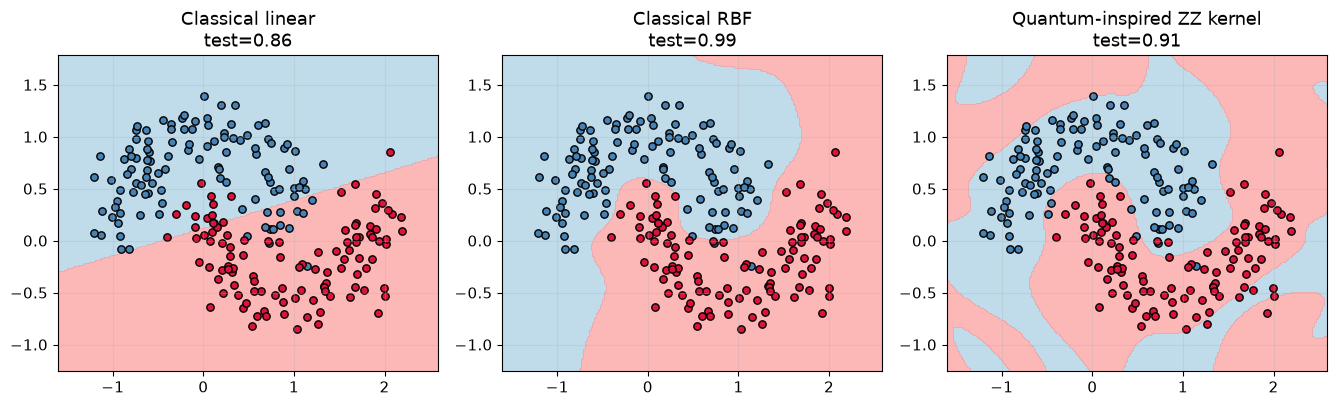

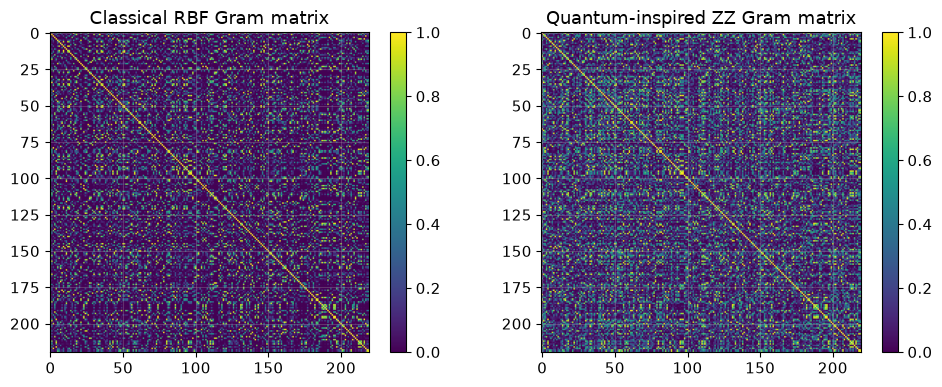

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

plot_decision(
    axes[0],
    lambda G: predict_logistic((G - mu) / sd, w_log, b_log),
    X_train, y_train, f'Classical linear\ntest={acc_log_te:.2f}',
)
plot_decision(
    axes[1],
    lambda G: predict_kernel_ridge(Xs_train, (G - mu) / sd, alpha_rbf, gamma_rbf)[0],
    X_train, y_train, f'Classical RBF\ntest={acc_rbf_te:.2f}',
)
plot_decision(
    axes[2],
    lambda G: predict_qkernel(Xs_train, (G - mu) / sd, alpha_q, scale_q)[0],
    X_train, y_train, f'Quantum-inspired ZZ kernel\ntest={acc_q_te:.2f}',
)
plt.tight_layout()
plt.show()

# Kernel matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(rbf_kernel(Xs_train, Xs_train), cmap='viridis')
axes[0].set_title('Classical RBF Gram matrix')
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(quantum_kernel(Xs_train, Xs_train), cmap='viridis')
axes[1].set_title('Quantum-inspired ZZ Gram matrix')
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


### What this experiment teaches

- On *this* toy problem, the ZZ quantum-inspired kernel is competitive with RBF --
  sometimes slightly better, sometimes not. That is the honest QML story on small data:
  **expressivity can match classical kernels**, but does not magically dominate them.
- The Gram matrices look different: different geometry in feature space.
  Advantage candidates are tasks where the quantum feature map is *hard to simulate*
  *and* aligns with the data-generating process -- rare, and hard to certify.


## 7. The real feature map: Qiskit `ZZFeatureMap` and the exact fidelity kernel

Section 6 *mimicked* the quantum kernel with six trigonometric features. That cartoon
is cheap and it works, but it is not the object a QPU would evaluate. Here we build
the actual circuit and compute the kernel exactly by statevector simulation:

$$
|\phi(x)\rangle \;=\; \Big[\,U_{ZZ}(x)\,H^{\otimes n}\Big]^{\,r}\,|0\rangle^{\otimes n},
\qquad
k_Q(x,x') \;=\; \big|\langle \phi(x')|\phi(x)\rangle\big|^2 ,
$$

with the standard phases $\varphi_i(x)=x_i$ on single qubits and
$\varphi_{ij}(x)=(\pi-x_i)(\pi-x_j)$ on the entangling pairs.

Two things become visible only when you run the real circuit:

- the mimic and the real map are **different kernels**, so an accuracy claim measured
  on the numpy stand-in does not transfer to hardware;
- exact simulation costs one statevector per sample and then a single matrix product,
  while a QPU pays one circuit *per pair* -- the topic of section 9.

In [8]:
FM_REPS = 2
fmap = zz_feature_map(feature_dimension=2, reps=FM_REPS, entanglement='linear')
print(fmap.draw(output='text', fold=104))


def qiskit_features(X, scale=1.0):
    'Exact |phi(x)> for every row of X: one statevector per sample.'
    return np.array([Statevector(fmap.assign_parameters(scale * np.asarray(x, float))).data
                     for x in X])


def fidelity_kernel(PA, PB):
    'k(x, x_) = |<phi(x_)|phi(x)>|^2 for two blocks of statevectors.'
    return np.abs(PA @ PB.conj().T) ** 2


def kernel_ridge_fit(K, y, lam=1e-2):
    return np.linalg.solve(K + lam * np.eye(len(y)), 2.0 * y - 1.0)


t0 = perf_counter()
Phi_train = qiskit_features(Xs_train)
Phi_test = qiskit_features(Xs_test)
t_sv = perf_counter() - t0

Kq_train = fidelity_kernel(Phi_train, Phi_train)
Kq_test = fidelity_kernel(Phi_test, Phi_train)
alpha_qk = kernel_ridge_fit(Kq_train, y_train)
acc_qk_tr = ((Kq_train @ alpha_qk > 0).astype(int) == y_train).mean()
acc_qk_te = ((Kq_test @ alpha_qk > 0).astype(int) == y_test).mean()

Km_train = quantum_kernel(Xs_train, Xs_train)
off = ~np.eye(len(y_train), dtype=bool)
corr = np.corrcoef(Kq_train[off], Km_train[off])[0, 1]
n_pts = len(Xs_train) + len(Xs_test)

print(f'Qiskit ZZ fidelity kernel   train={acc_qk_tr:.3f}  test={acc_qk_te:.3f}')
print(f'numpy mimic ZZ kernel       train={acc_q_tr:.3f}  test={acc_q_te:.3f}')
print(f'classical RBF kernel        train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')
print(f'\n{n_pts} statevectors in {t_sv:.2f}s ({1e3 * t_sv / n_pts:.2f} ms each)')
print(f'mimic vs real, off-diagonal entries: corr={corr:+.3f}  '
      f'max|diff|={np.abs(Kq_train - Km_train)[off].max():.3f}  '
      f'mean k_real={Kq_train[off].mean():.3f} vs mean k_mimic={Km_train[off].mean():.3f}')

   ┌───┐┌───────────┐                                          ┌───┐┌───────────┐     »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├┤ P(2*x[0]) ├──■──»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐├───┤├───────────┤┌─┴─┐»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├┤ H ├┤ P(2*x[1]) ├┤ X ├»
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘└───┘└───────────┘└───┘»
«                                        
«0: ──────────────────────────────────■──
«   ┌──────────────────────────────┐┌─┴─┐
«1: ┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
«   └──────────────────────────────┘└───┘
Qiskit ZZ fidelity kernel   train=0.641  test=0.580
numpy mimic ZZ kernel       train=0.918  test=0.910
classical RBF kernel        train=0.986  test=0.990

320 statevectors in 0.55s (1.71 ms each)
mimic vs real, off-diagonal entries: corr=+0.080  max|diff|=0.968  mean k_real=0.289 vs mean k_mimic=0.220


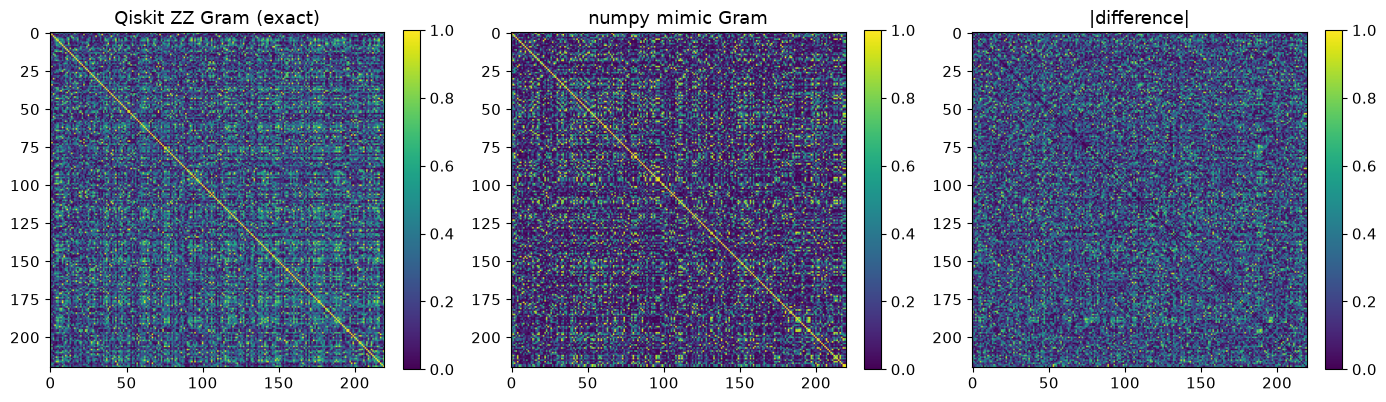

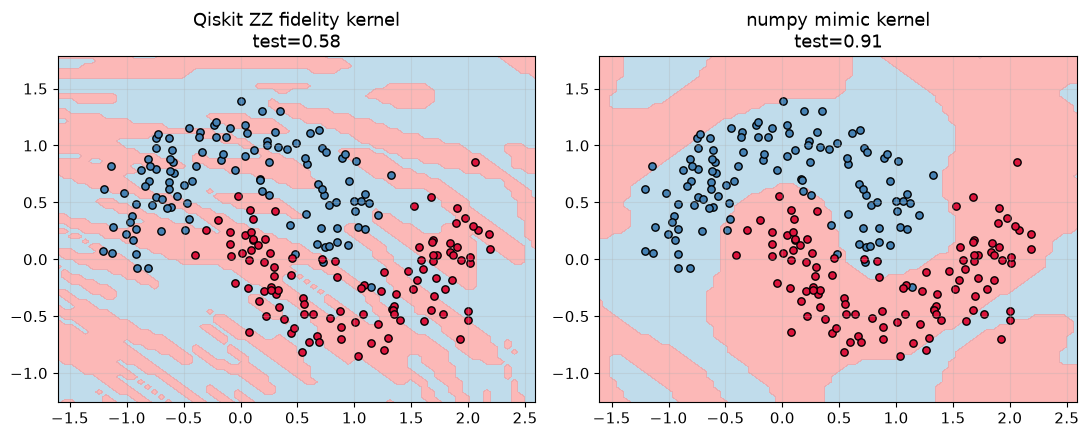

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
for ax, M, ttl in zip(axes,
                      [Kq_train, Km_train, np.abs(Kq_train - Km_train)],
                      ['Qiskit ZZ Gram (exact)', 'numpy mimic Gram', '|difference|']):
    im = ax.imshow(M, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(ttl)
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision(
    axes[0],
    lambda G: (fidelity_kernel(qiskit_features((G - mu) / sd), Phi_train) @ alpha_qk > 0).astype(int),
    X_train, y_train, f'Qiskit ZZ fidelity kernel\ntest={acc_qk_te:.2f}', res=70,
)
plot_decision(
    axes[1],
    lambda G: predict_qkernel(Xs_train, (G - mu) / sd, alpha_q, scale_q)[0],
    X_train, y_train, f'numpy mimic kernel\ntest={acc_q_te:.2f}', res=70,
)
plt.tight_layout()
plt.show()

### Reading the real kernel

The two Gram matrices are not small perturbations of each other. Their off-diagonal
entries are essentially **uncorrelated** (correlation around $0.08$, with pairs that
differ by almost the full range), even though their average similarity level is in the
same ballpark. They encode different geometries, so an accuracy measured on the numpy
stand-in says nothing about the circuit: at unit bandwidth the real map scores close to
chance while the mimic looks competitive.

The decision boundaries make the same point visually -- the exact kernel carves a
fragmented frontier that overfits the training points. Before blaming the feature map,
though, check its bandwidth: that is the next section, and it changes the verdict.

## 8. Bandwidth: the hyperparameter that decides the whole story

A quantum kernel has a knob that is easy to forget: the scale applied to the data
before encoding, $x \mapsto s\,x$. It plays the role of $\gamma$ in the RBF kernel,
and it controls how much of the Hilbert space the states explore.

- $s$ **too small**: all states are nearly parallel, every fidelity is close to $1$,
  the Gram matrix is almost rank-one and the model can only express what a linear
  classifier expresses.
- $s$ **too large**: the encoding scrambles the geometry. Nearby points stop having
  similar states, the kernel loses its relation to distance in input space, and both
  train and test accuracy collapse. With many qubits this is the exponential
  concentration regime, where off-diagonal fidelities fall towards $2^{-n}$ and the
  Gram matrix tends to the identity (memorise the training set, predict noise);
  with only $2$ qubits the floor is $1/4$, so we see the scrambling but not yet the
  clean identity limit.

The sweep below reproduces the bandwidth result of Shaydulin & Wild (2022) and
Canatar et al. (2022) on our toy set: generalisation is *not* a property of the
feature map alone, it is a property of the map **plus** its bandwidth.

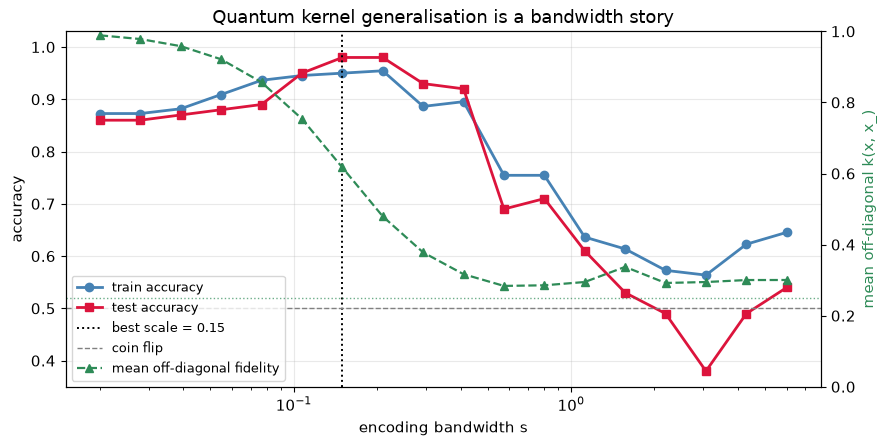

  scale s   train    test  mean k_ij
    0.020   0.873   0.860      0.989
    0.028   0.873   0.860      0.978
    0.039   0.882   0.870      0.958
    0.055   0.909   0.880      0.921
    0.077   0.936   0.890      0.857
    0.107   0.945   0.950      0.754
    0.150   0.950   0.980      0.617
    0.209   0.955   0.980      0.479
    0.293   0.886   0.930      0.378
    0.410   0.895   0.920      0.317
    0.573   0.755   0.690      0.284
    0.801   0.755   0.710      0.285
    1.121   0.636   0.610      0.295
    1.568   0.614   0.530      0.337
    2.193   0.573   0.490      0.292
    3.067   0.564   0.380      0.295
    4.290   0.623   0.490      0.300
    6.000   0.645   0.540      0.300

worst scale s=3.07 -> test=0.380
best  scale s=0.15 -> train=0.950  test=0.980
classical RBF (gamma=1.5)            train=0.986  test=0.990
mean off-diagonal fidelity at s=4: 0.300   (1/2^n = 0.250)


In [10]:
scales = np.geomspace(0.02, 6.0, 18)
band = []
for s in scales:
    Ptr, Pte = qiskit_features(Xs_train, scale=s), qiskit_features(Xs_test, scale=s)
    Ktr, Kte = fidelity_kernel(Ptr, Ptr), fidelity_kernel(Pte, Ptr)
    a = kernel_ridge_fit(Ktr, y_train)
    band.append((s,
                 ((Ktr @ a > 0).astype(int) == y_train).mean(),
                 ((Kte @ a > 0).astype(int) == y_test).mean(),
                 Ktr[off].mean()))
band = np.array(band)
BEST_SCALE = float(band[np.argmax(band[:, 2]), 0])

Phi_train_b = qiskit_features(Xs_train, scale=BEST_SCALE)
Phi_test_b = qiskit_features(Xs_test, scale=BEST_SCALE)
Kqb_train = fidelity_kernel(Phi_train_b, Phi_train_b)
Kqb_test = fidelity_kernel(Phi_test_b, Phi_train_b)
alpha_qkb = kernel_ridge_fit(Kqb_train, y_train)
acc_qkb_tr = ((Kqb_train @ alpha_qkb > 0).astype(int) == y_train).mean()
acc_qkb_te = ((Kqb_test @ alpha_qkb > 0).astype(int) == y_test).mean()

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.semilogx(band[:, 0], band[:, 1], 'o-', color='steelblue', lw=2, label='train accuracy')
ax.semilogx(band[:, 0], band[:, 2], 's-', color='crimson', lw=2, label='test accuracy')
ax.axvline(BEST_SCALE, color='k', ls=':', lw=1.4, label=f'best scale = {BEST_SCALE:.2f}')
ax.axhline(0.5, color='gray', ls='--', lw=1, label='coin flip')
ax.set_xlabel('encoding bandwidth s')
ax.set_ylabel('accuracy')
ax.set_ylim(0.35, 1.03)
ax.set_title('Quantum kernel generalisation is a bandwidth story')
ax2 = ax.twinx()
ax2.semilogx(band[:, 0], band[:, 3], '^--', color='seagreen', lw=1.6,
             label='mean off-diagonal fidelity')
ax2.axhline(0.25, color='seagreen', ls=':', lw=1, alpha=0.7)
ax2.set_ylabel('mean off-diagonal k(x, x_)', color='seagreen')
ax2.set_ylim(0, 1)
ax2.grid(False)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

print(f'{"scale s":>9}{"train":>8}{"test":>8}{"mean k_ij":>11}')
for s, a_tr, a_te, k_off in band:
    print(f'{s:>9.3f}{a_tr:>8.3f}{a_te:>8.3f}{k_off:>11.3f}')
print()
print(f'worst scale s={band[np.argmin(band[:, 2]), 0]:.2f} -> test={band[:, 2].min():.3f}')
print(f'best  scale s={BEST_SCALE:.2f} -> train={acc_qkb_tr:.3f}  test={acc_qkb_te:.3f}')
print(f'classical RBF (gamma={gamma_rbf})            train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')
print(f'mean off-diagonal fidelity at s=4: {band[-1, 3]:.3f}   (1/2^n = {1 / 2 ** fmap.num_qubits:.3f})')

### Reading the bandwidth sweep

One knob moves the same circuit across the whole spectrum: test accuracy runs from
$0.86$ at $s=0.02$ (exactly the logistic-regression score -- the near rank-one kernel
buys nothing over a straight line) up to $0.98$ around $s\approx0.15$, then down to
$0.38$, *below* a coin flip, at $s\approx3$. The gap between the worst and the best
setting is larger than any classical-versus-quantum gap discussed in this notebook.

That is the practical warning for a thesis: comparing a quantum kernel against a
*tuned* RBF without tuning the encoding bandwidth reports a hyperparameter, not a
physical effect. Note also that the winning bandwidth is a **small** one, where the
Gram matrix is far from the identity -- exactly the regime that shot noise attacks
hardest, as the next section shows.

## 9. The bill nobody prints: shot noise and pair counting

Simulation gave us $k_Q$ exactly. Hardware does not: each entry is estimated with the
compute-uncompute trick, i.e. by preparing $U^\dagger(x')U(x)|0\rangle$ and counting how
often the all-zeros string comes back. With $M$ shots,

$$
\hat{k} \sim \frac{1}{M}\,\mathrm{Binomial}(M, k),
\qquad
\mathrm{std}(\hat k) = \sigma = \sqrt{\tfrac{k(1-k)}{M}} ,
$$

and the number of circuits is quadratic in the dataset:
$\tfrac{N_{tr}(N_{tr}-1)}{2} + N_{te}N_{tr}$.

The subtle part is not the per-entry error, it is what it does to the *matrix*. The
estimated Gram is $\hat K = K + E$ with $E$ a symmetric random matrix, whose extreme
eigenvalues sit near $\pm 2\sigma\sqrt{N}$ (Wigner semicircle). Kernel ridge inverts
$\hat K + \lambda I$, so unless

$$
\lambda \;\gtrsim\; 2\sigma\sqrt{N} \;=\; 2\sqrt{\tfrac{k(1-k)N}{M}} ,
$$

the solution is dominated by noise directions -- and buying that much regularisation
costs accuracy. Below we compare a naive $\lambda$, a generous fixed one, and a
$\lambda$ chosen on a validation block of the training set (never on the test set).

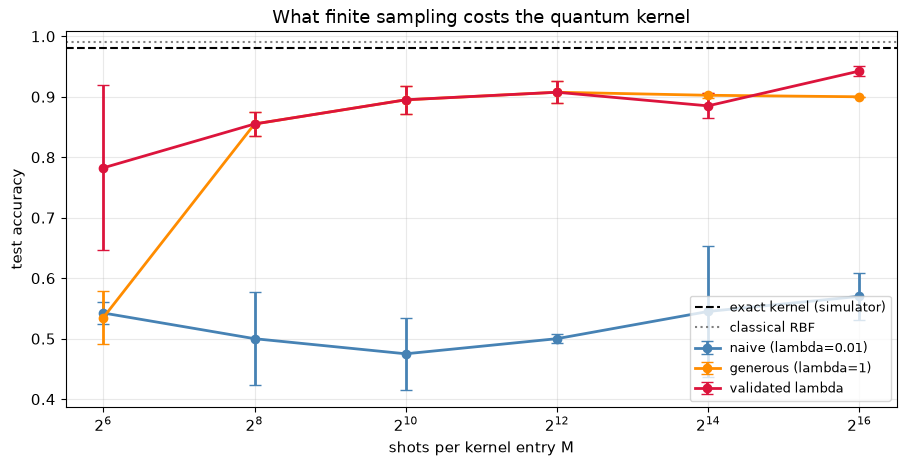

  shots M  noise radius  lambda*   naive (lambda=0.01)   generous (lambda=1)      validated lambda
       64          1.44        5           0.542 +/-0.018           0.535 +/-0.043           0.782 +/-0.137
      256          0.72        1           0.500 +/-0.076           0.855 +/-0.021           0.855 +/-0.021
     1024          0.36        1           0.475 +/-0.059           0.895 +/-0.023           0.895 +/-0.023
     4096          0.18        1           0.500 +/-0.007           0.908 +/-0.018           0.908 +/-0.018
    16384          0.09      0.1           0.545 +/-0.108           0.902 +/-0.004           0.885 +/-0.021
    65536          0.04      0.1           0.570 +/-0.039           0.900 +/-0.000           0.942 +/-0.008
    exact          0.00     0.01           0.980           0.980           0.980

M=   256: 46,090 circuits x 256 shots = 11,799,040 shots ->     0.7 h at 5,000 shots/s
M=  4096: 46,090 circuits x 4,096 shots = 188,784,640 shots ->    10.5 h at 5,000 sh

In [11]:
N_TR, N_TE = len(y_train), len(y_test)
n_pairs = N_TR * (N_TR - 1) // 2 + N_TE * N_TR
shot_grid = [64, 256, 1024, 4096, 16384, 65536]
lam_grid = [1e-2, 1e-1, 1.0, 5.0, 20.0]
N_FIT = 170  # inner split: pick lambda without ever touching the test set
REPS = 4
rng_shots = np.random.default_rng(7)


def sampled_gram(K, M, symmetric):
    'Replace exact fidelities by M-shot binomial estimates.'
    Kn = rng_shots.binomial(M, np.clip(K, 0, 1)) / M
    if symmetric:
        up = np.triu(Kn, 1)
        Kn = up + up.T + np.eye(len(K))
    return Kn


fit_sl, val_sl = slice(0, N_FIT), slice(N_FIT, N_TR)
curves = {'naive (lambda=0.01)': [], 'generous (lambda=1)': [], 'validated lambda': []}
radii, chosen = [], []

for M in shot_grid:
    per = {k: [] for k in curves}
    lam_pick = []
    for _ in range(REPS):
        Ktr_n = sampled_gram(Kqb_train, M, True)
        Kte_n = sampled_gram(Kqb_test, M, False)
        best_lam, best_val = lam_grid[0], -1.0
        for lam in lam_grid:
            a = kernel_ridge_fit(Ktr_n[fit_sl, fit_sl], y_train[fit_sl], lam=lam)
            v = ((Ktr_n[val_sl, fit_sl] @ a > 0).astype(int) == y_train[val_sl]).mean()
            if v > best_val:
                best_val, best_lam = v, lam
        lam_pick.append(best_lam)
        for key, lam in zip(curves, [1e-2, 1.0, best_lam]):
            a = kernel_ridge_fit(Ktr_n, y_train, lam=lam)
            per[key].append(((Kte_n @ a > 0).astype(int) == y_test).mean())
    for key in curves:
        curves[key].append((np.mean(per[key]), np.std(per[key])))
    sigma = np.sqrt(np.mean(Kqb_train * (1 - Kqb_train)) / M)
    radii.append(2 * sigma * np.sqrt(N_TR))
    chosen.append(np.median(lam_pick))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
for (key, vals), color in zip(curves.items(), ['steelblue', 'darkorange', 'crimson']):
    m = np.array([v[0] for v in vals])
    s = np.array([v[1] for v in vals])
    ax.errorbar(shot_grid, m, yerr=s, fmt='o-', lw=2, capsize=4, color=color, label=key)
ax.axhline(acc_qkb_te, color='k', ls='--', lw=1.5, label='exact kernel (simulator)')
ax.axhline(acc_rbf_te, color='gray', ls=':', lw=1.5, label='classical RBF')
ax.set_xscale('log', base=2)
ax.set_xlabel('shots per kernel entry M')
ax.set_ylabel('test accuracy')
ax.set_title('What finite sampling costs the quantum kernel')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f'{"shots M":>9}{"noise radius":>14}{"lambda*":>9}' +
      ''.join(f'{k:>22}' for k in curves))
for i, M in enumerate(shot_grid):
    row = ''.join(f'{curves[k][i][0]:>16.3f} +/-{curves[k][i][1]:.3f}' for k in curves)
    print(f'{M:>9}{radii[i]:>14.2f}{chosen[i]:>9g}' + row)
print(f'{"exact":>9}{0.0:>14.2f}{1e-2:>9g}' + f'{acc_qkb_te:>16.3f}' * 3)

rate = 5_000  # shots per second, generous for a cloud QPU including overhead
print()
for M in (256, 4096, 65536):
    total = n_pairs * M
    print(f'M={M:>6}: {n_pairs:,} circuits x {M:,} shots = {total:,} shots '
          f'-> {total / rate / 3600:7.1f} h at {rate:,} shots/s')
print(f'\nthe same 320-point Gram matrix on the simulator: {t_sv:.2f}s')

### Reading the bill

The naive ridge never recovers: with $\lambda=0.01$ the accuracy stays near a coin flip
even at $65\,536$ shots per entry, because the noise matrix still dominates the inverse.
Raise $\lambda$ above the noise radius and the model comes back to life -- but it lands
below the simulator number and only creeps upwards as $M$ grows, since the ridge that
suppresses the noise also suppresses the signal. The validated-$\lambda$ curve is the
honest one: it picks a large ridge at low shot counts and relaxes as the estimate
sharpens.

Then there is the wall clock. A 320-point toy already needs $46\,090$ circuits; at a
generous $5\,000$ shots/s that is well under an hour for a coarse estimate and days for
a sharp one, to approximate something the simulator does in half a second. This is why
quantum-kernel demonstrations stay small, and why "we matched the RBF baseline" is a
statement about expressivity, never about cost.

## 10. Hybrid flavour: a tiny variational model

Hybrid QML trains parameters $\theta$ of a circuit $U(\theta)$ by a **classical
optimizer**, measuring an expectation that becomes the loss.

We simulate a minimal version:

$$
|\psi(x;\theta)\rangle
=
R_y(\theta_2)\,
R_y(x_2)\,
R_y(\theta_1)\,
R_y(x_1)\,|0\rangle
$$

and use $z = \langle Z\rangle$ as a score (one qubit -- pedagogical, not state-of-the-art).
Training uses finite-difference gradients (parameter-shift spirit) and SGD.


In [12]:
def ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)


def variational_score(x, theta):
    # 1-qubit toy VQC: encode x, then trainable rotations
    psi = np.array([1, 0], dtype=complex)
    for gate in (ry(x[0]), ry(theta[0]), ry(x[1]), ry(theta[1])):
        psi = gate @ psi
    # <Z> = |a|^2 - |b|^2
    return float(np.abs(psi[0]) ** 2 - np.abs(psi[1]) ** 2)


def vqc_predict(X, theta):
    scores = np.array([variational_score(x, theta) for x in X])
    return (scores > 0).astype(int), scores


def train_vqc(X, y, steps=120, lr=0.25, seed=0):
    r = np.random.default_rng(seed)
    theta = r.normal(0, 0.3, size=2)
    yt = 2 * y - 1.0
    hist_loss, hist_acc = [], []
    eps = 1e-1
    for t in range(steps):
        # predictions
        scores = np.array([variational_score(x, theta) for x in X])
        # soft hinge-ish loss
        margins = yt * scores
        loss = np.mean(np.maximum(0.0, 1.0 - margins)) + 1e-3 * np.sum(theta ** 2)
        # finite-difference gradient (parameter-shift style)
        grad = np.zeros_like(theta)
        for j in range(len(theta)):
            tp, tm = theta.copy(), theta.copy()
            tp[j] += eps
            tm[j] -= eps
            sp = np.array([variational_score(x, tp) for x in X])
            sm = np.array([variational_score(x, tm) for x in X])
            lp = np.mean(np.maximum(0.0, 1.0 - yt * sp))
            lm = np.mean(np.maximum(0.0, 1.0 - yt * sm))
            grad[j] = (lp - lm) / (2 * eps) + 2e-3 * theta[j]
        theta -= lr * grad
        pred = (scores > 0).astype(int)
        hist_loss.append(loss)
        hist_acc.append((pred == y).mean())
    return theta, np.array(hist_loss), np.array(hist_acc)


theta_hat, loss_vqc, acc_vqc = train_vqc(Xs_train, y_train)
pred_v_tr, _ = vqc_predict(Xs_train, theta_hat)
pred_v_te, _ = vqc_predict(Xs_test, theta_hat)
acc_v_tr = (pred_v_tr == y_train).mean()
acc_v_te = (pred_v_te == y_test).mean()
print(f'Hybrid VQC (1-qubit toy)  train={acc_v_tr:.3f}  test={acc_v_te:.3f}')
print(f'Learned theta = {np.round(theta_hat, 3)}')


Hybrid VQC (1-qubit toy)  train=0.627  test=0.750
Learned theta = [0.861 0.788]


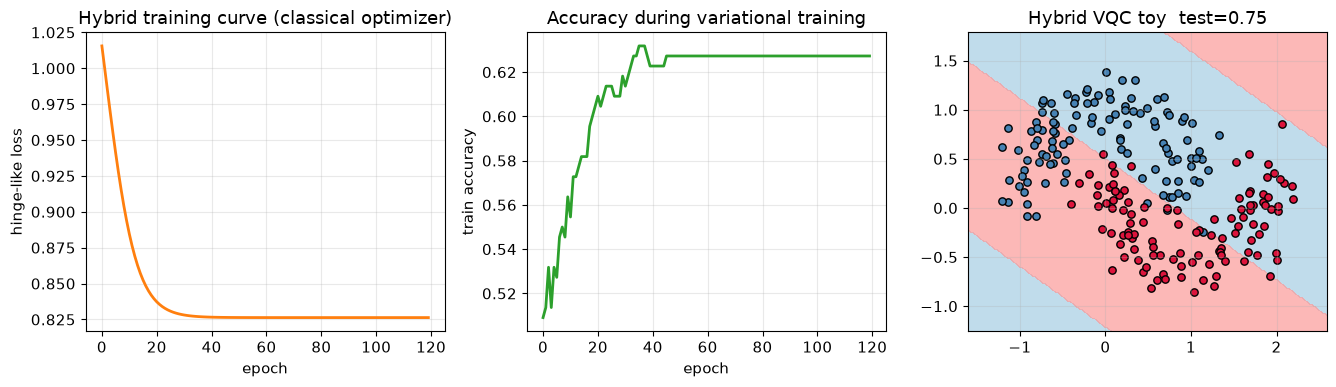

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

axes[0].plot(loss_vqc, lw=2, color='C1')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('hinge-like loss')
axes[0].set_title('Hybrid training curve (classical optimizer)')

axes[1].plot(acc_vqc, lw=2, color='C2')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('train accuracy')
axes[1].set_title('Accuracy during variational training')

plot_decision(
    axes[2],
    lambda G: vqc_predict((G - mu) / sd, theta_hat)[0],
    X_train, y_train,
    f'Hybrid VQC toy  test={acc_v_te:.2f}',
)
plt.tight_layout()
plt.show()


### Hybrid takeaway

Even a ridiculously small VQC can *fit something* on a toy set -- that proves
the hybrid loop works (circuit + classical optimizer). It does **not** prove a
quantum advantage. On real finance data you compete with XGBoost; a shallow VQC
usually loses unless the problem is carefully engineered.


## 11. The toy VQC is a linear model in disguise -- and an entangling repair

Before comparing the hybrid model with anything, it pays to ask what it actually
computes. All four gates of section 10 rotate about the *same* axis, and $R_y$
rotations commute, so the circuit collapses:

$$
R_y(\theta_2)R_y(x_2)R_y(\theta_1)R_y(x_1)|0\rangle
= R_y(x_1 + x_2 + \theta_1 + \theta_2)|0\rangle,
\qquad
\langle Z\rangle = \cos(x_1 + x_2 + \theta_1 + \theta_2).
$$

Two trainable parameters, **one** effective degree of freedom, and a decision boundary
made of parallel lines in $x_1+x_2$. It is a linear classifier wrapped in a cosine --
no entanglement, nothing a QPU is needed for. The cell below verifies the identity
numerically instead of trusting the algebra.

The repair is the standard one: **entanglement plus data re-uploading**. We build a
2-qubit hardware-efficient ansatz, alternating trainable $R_y(w_i x_i + b_i)$ layers
with CZ entanglers, cross-check the fast numpy simulation against Qiskit statevectors,
and train it with COBYLA on a hinge loss.

max |cos(x1 + x2 + sum theta) - <Z>| = 5.55e-16
sum of trained angles = 1.6484 rad -- the only quantity the model uses


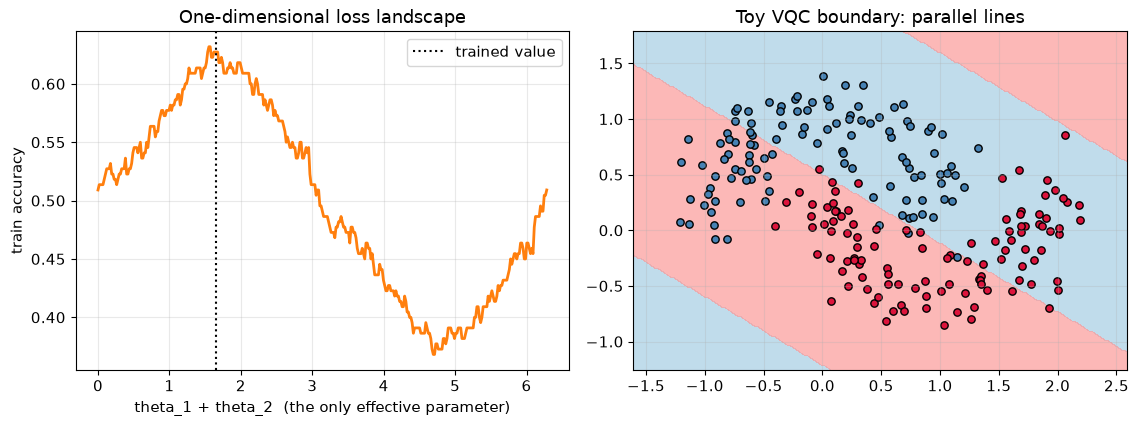

In [14]:
theta_sum = float(theta_hat.sum())
analytic = np.cos(Xs_test[:, 0] + Xs_test[:, 1] + theta_sum)
simulated = np.array([variational_score(x, theta_hat) for x in Xs_test])
print(f'max |cos(x1 + x2 + sum theta) - <Z>| = {np.abs(analytic - simulated).max():.2e}')
print(f'sum of trained angles = {theta_sum:.4f} rad -- the only quantity the model uses')

grid_sum = np.linspace(0, 2 * np.pi, 361)
acc_curve = np.array([(((np.cos(Xs_train[:, 0] + Xs_train[:, 1] + t) > 0).astype(int)) == y_train).mean()
                      for t in grid_sum])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].plot(grid_sum, acc_curve, lw=2, color='C1')
axes[0].axvline(theta_sum % (2 * np.pi), color='k', ls=':', label='trained value')
axes[0].set_xlabel('theta_1 + theta_2  (the only effective parameter)')
axes[0].set_ylabel('train accuracy')
axes[0].set_title('One-dimensional loss landscape')
axes[0].legend()
plot_decision(
    axes[1],
    lambda G: (np.cos(((G - mu) / sd)[:, 0] + ((G - mu) / sd)[:, 1] + theta_sum) > 0).astype(int),
    X_train, y_train, 'Toy VQC boundary: parallel lines',
)
plt.tight_layout()
plt.show()

     ┌──────────────┐   ┌─────────────┐    ┌──────────────┐
q_0: ┤ Ry(-0.87267) ├─■─┤ Ry(-2.3734) ├──■─┤ Ry(-0.86227) ├
     └┬────────────┬┘ │ ├─────────────┴┐ │ └┬────────────┬┘
q_1: ─┤ Ry(2.0106) ├──■─┤ Ry(-0.13396) ├─■──┤ Ry(2.0317) ├─
      └────────────┘    └──────────────┘    └────────────┘ 
numpy vs Qiskit statevector, max |diff| = 2.22e-16

Entangling VQC (3 layers, 12 params, hinge=0.261)  train=0.959  test=0.980
Commuting toy VQC (1 effective param)                     train=0.627  test=0.750
Classical RBF kernel                                      train=0.986  test=0.990


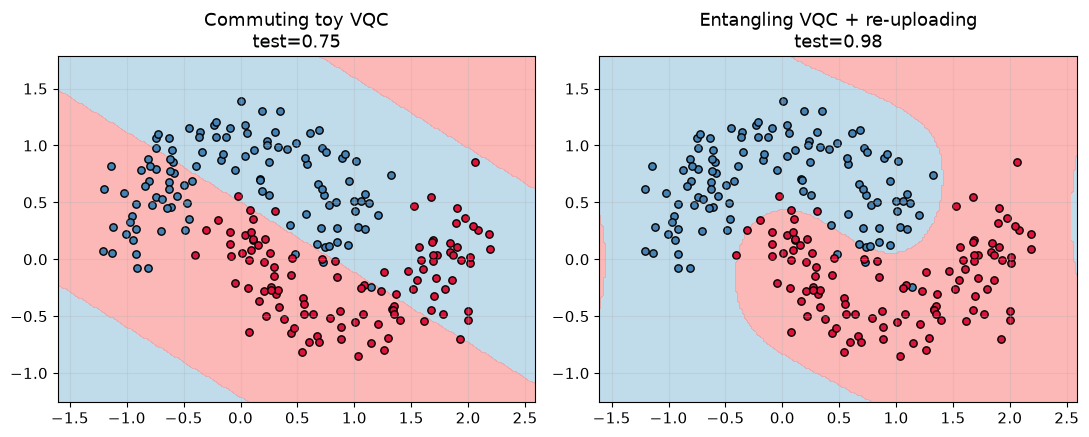

In [15]:
VQC_LAYERS = 3


def _ry_batch(angles):
    c, s = np.cos(angles / 2), np.sin(angles / 2)
    R = np.empty(angles.shape + (2, 2))
    R[..., 0, 0], R[..., 0, 1] = c, -s
    R[..., 1, 0], R[..., 1, 1] = s, c
    return R


def entangling_scores(X, params, layers=VQC_LAYERS):
    'Vectorised <Z_0> for a 2-qubit re-uploading ansatz; psi[n, q0, q1].'
    p = params.reshape(layers, 4)
    psi = np.zeros((len(X), 2, 2))
    psi[:, 0, 0] = 1.0
    for ell in range(layers):
        w1, b1, w2, b2 = p[ell]
        psi = np.einsum('nik,nkj->nij', _ry_batch(w1 * X[:, 0] + b1), psi)
        psi = np.einsum('njk,nik->nij', _ry_batch(w2 * X[:, 1] + b2), psi)
        if ell < layers - 1:
            psi[:, 1, 1] *= -1.0  # CZ
    prob = psi ** 2
    return prob[:, 0, :].sum(1) - prob[:, 1, :].sum(1)


def entangling_circuit(x, params, layers=VQC_LAYERS):
    'The same ansatz as a Qiskit circuit, used to validate the fast path.'
    p = params.reshape(layers, 4)
    qc = QuantumCircuit(2)
    for ell in range(layers):
        w1, b1, w2, b2 = p[ell]
        qc.ry(w1 * x[0] + b1, 0)
        qc.ry(w2 * x[1] + b2, 1)
        if ell < layers - 1:
            qc.cz(0, 1)
    return qc


check_params = rng.normal(0, 1.0, 4 * VQC_LAYERS)
Z0 = SparsePauliOp('IZ')
qiskit_vals = np.array([Statevector(entangling_circuit(x, check_params)).expectation_value(Z0).real
                        for x in Xs_test[:6]])
numpy_vals = entangling_scores(Xs_test[:6], check_params)
print(entangling_circuit(Xs_test[0], check_params).draw(output='text', fold=104))
print(f'numpy vs Qiskit statevector, max |diff| = {np.abs(qiskit_vals - numpy_vals).max():.2e}')


def train_entangling_vqc(X, y, layers=VQC_LAYERS, restarts=4, seed=3):
    r = np.random.default_rng(seed)
    yt = 2.0 * y - 1.0

    def loss(params):
        margins = yt * entangling_scores(X, params, layers)
        return float(np.mean(np.maximum(0.0, 1.0 - margins)) + 1e-3 * np.sum(params ** 2))

    best = (np.inf, None)
    for _ in range(restarts):
        p0 = r.normal(0, 1.0, 4 * layers)
        res = minimize(loss, p0, method='COBYLA', options={'maxiter': 900, 'rhobeg': 0.6})
        if res.fun < best[0]:
            best = (float(res.fun), res.x)
    return best[1], best[0]


params_ent, loss_ent = train_entangling_vqc(Xs_train, y_train)
acc_ent_tr = ((entangling_scores(Xs_train, params_ent) > 0).astype(int) == y_train).mean()
acc_ent_te = ((entangling_scores(Xs_test, params_ent) > 0).astype(int) == y_test).mean()
print(f'\nEntangling VQC ({VQC_LAYERS} layers, {4 * VQC_LAYERS} params, hinge={loss_ent:.3f})'
      f'  train={acc_ent_tr:.3f}  test={acc_ent_te:.3f}')
print(f'Commuting toy VQC (1 effective param)                     '
      f'train={acc_v_tr:.3f}  test={acc_v_te:.3f}')
print(f'Classical RBF kernel                                      '
      f'train={acc_rbf_tr:.3f}  test={acc_rbf_te:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision(axes[0], lambda G: vqc_predict((G - mu) / sd, theta_hat)[0],
              X_train, y_train, f'Commuting toy VQC\ntest={acc_v_te:.2f}')
plot_decision(axes[1], lambda G: (entangling_scores((G - mu) / sd, params_ent) > 0).astype(int),
              X_train, y_train, f'Entangling VQC + re-uploading\ntest={acc_ent_te:.2f}')
plt.tight_layout()
plt.show()

### What the repair buys

Adding CZ gates and re-uploading the data three times turns a straight line into a
curved, non-monotone boundary, and the test accuracy jumps accordingly. The point is
not that the entangling circuit wins -- it still has to beat the RBF kernel, and on
this dataset it roughly ties at best. The point is methodological:

- **check the algebra of your ansatz before claiming it is quantum.** Commuting
  generators, or circuits without entanglement, are classically trivial by construction;
- the numpy fast path and the Qiskit statevector agree to machine precision, which is
  what makes the cheap sweep in the next sections legitimate;
- the honest comparison always includes a tuned classical baseline on the same split.

## 12. Scaling sketches: where asymptotics differ

Two classic complexity cartoons used in QML talks:

1. **Estimating an expectation / probability** to error $\varepsilon$:
   classical Monte Carlo $\sim 1/\varepsilon^2$ vs Amplitude Estimation $\sim 1/\varepsilon$
   (same story as the VaR notebooks).
2. **Kernel matrix entry** $k(x,x')$: classical explicit features cost $O(D)$ in
   dimension $D$; some quantum kernels claim $D$ exponential in qubits while the
   circuit depth stays polynomial -- *if* you evaluate the kernel on a QPU.


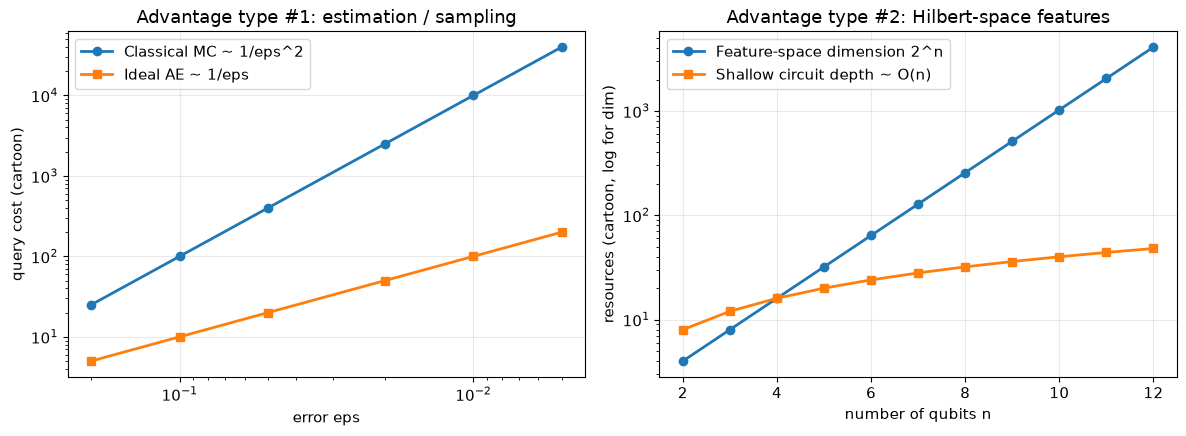

These plots are complexity cartoons -- they ignore data loading and noise.


In [16]:
eps = np.array([0.2, 0.1, 0.05, 0.02, 0.01, 0.005])
mc_cost = 1.0 / eps ** 2
ae_cost = 1.0 / eps

qubits = np.arange(2, 13)
dim_explicit = 2 ** qubits          # Hilbert dimension
depth_circuit = 4 * qubits         # shallow feature-map depth (cartoon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(eps, mc_cost, 'o-', lw=2, label='Classical MC ~ 1/eps^2')
ax.loglog(eps, ae_cost, 's-', lw=2, label='Ideal AE ~ 1/eps')
ax.invert_xaxis()
ax.set_xlabel('error eps')
ax.set_ylabel('query cost (cartoon)')
ax.set_title('Advantage type #1: estimation / sampling')
ax.legend()

ax = axes[1]
ax.semilogy(qubits, dim_explicit, 'o-', lw=2, label='Feature-space dimension 2^n')
ax.plot(qubits, depth_circuit, 's-', lw=2, label='Shallow circuit depth ~ O(n)')
ax.set_xlabel('number of qubits n')
ax.set_ylabel('resources (cartoon, log for dim)')
ax.set_title('Advantage type #2: Hilbert-space features')
ax.legend()

plt.tight_layout()
plt.show()
print('These plots are complexity cartoons -- they ignore data loading and noise.')


## 13. Caveats that a good thesis must mention

1. **Data loading / QRAM.** Many exponential speedups assume cheap coherent access
   to classical data. Loading a dense dataset can cost as much as solving the problem.
2. **Barren plateaus.** In hybrid training, gradients can vanish exponentially with
   qubit number -- the optimizer sees a flat loss landscape. The experiment below
   *measures* this on real random circuits instead of drawing the expected curve, and
   it separates the two regimes that are often conflated: a **global** observable
   $Z^{\otimes n}$ versus a **local** one $Z_0Z_1$ (Cerezo et al., 2021).
3. **Noise.** NISQ measurements are noisy; kernel entries and gradients degrade.
4. **Classical shadow / dequantization.** Some "quantum" linear-algebra claims were
   matched by clever classical algorithms given similar sampling assumptions.
5. **Baselines.** Beating a linear model is not enough; beat a tuned classical kernel
   or gradient-boosted tree on the *same* splits.


7 circuit families measured in 18.2s (depth = n layers, 200 random parameter draws each)


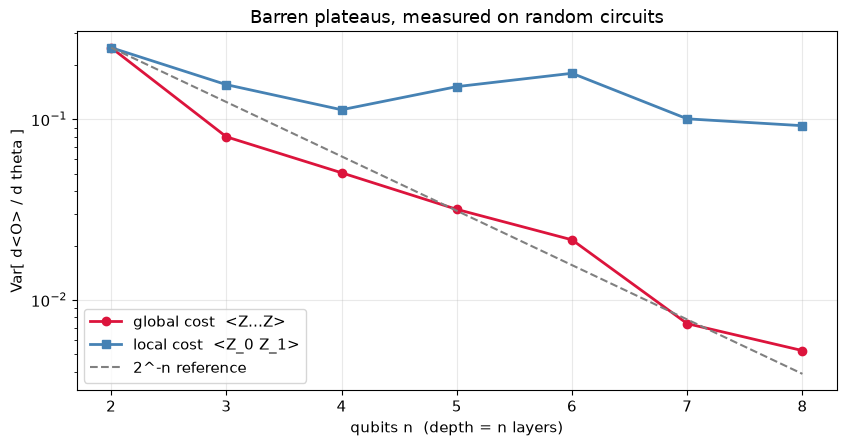

global cost: variance ~ 2^(-0.89 n)
local  cost: variance ~ 2^(-0.17 n)


In [17]:
def hea_circuit(n_qubits, n_layers, params):
    'Hardware-efficient ansatz: Ry layer + CZ chain, the usual barren-plateau testbed.'
    qc = QuantumCircuit(n_qubits)
    k = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(params[k], q)
            k += 1
        for q in range(n_qubits - 1):
            qc.cz(q, q + 1)
    return qc


def gradient_samples(n_qubits, n_samples=200, seed=0):
    'Parameter-shift gradient of a mid-circuit angle, for a global and a local cost.'
    r = np.random.default_rng(seed + n_qubits)
    n_layers = n_qubits
    n_par = n_qubits * n_layers
    # qubit 0 in the middle layer: always inside the light cone of Z_0 Z_1, so the
    # two observables are compared on the same parameter of the same circuits
    target = (n_layers // 2) * n_qubits
    global_obs = SparsePauliOp('Z' * n_qubits)
    local_obs = SparsePauliOp('I' * (n_qubits - 2) + 'ZZ')
    g_glob, g_loc = [], []
    for _ in range(n_samples):
        theta = r.uniform(0, 2 * np.pi, n_par)
        vals = []
        for shift in (+np.pi / 2, -np.pi / 2):
            tp = theta.copy()
            tp[target] += shift
            sv = Statevector(hea_circuit(n_qubits, n_layers, tp))
            vals.append((sv.expectation_value(global_obs).real,
                         sv.expectation_value(local_obs).real))
        g_glob.append(0.5 * (vals[0][0] - vals[1][0]))
        g_loc.append(0.5 * (vals[0][1] - vals[1][1]))
    return np.var(g_glob), np.var(g_loc)


qubit_list = np.arange(2, 9)
t0 = perf_counter()
measured = np.array([gradient_samples(int(n)) for n in qubit_list])
print(f'{len(qubit_list)} circuit families measured in {perf_counter() - t0:.1f}s '
      f'(depth = n layers, 200 random parameter draws each)')

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.semilogy(qubit_list, measured[:, 0], 'o-', lw=2, color='crimson',
            label='global cost  <Z...Z>')
ax.semilogy(qubit_list, measured[:, 1], 's-', lw=2, color='steelblue',
            label='local cost  <Z_0 Z_1>')
ax.semilogy(qubit_list, measured[0, 0] * 2.0 ** -(qubit_list - 2), '--', color='gray',
            label='2^-n reference')
ax.set_xlabel('qubits n  (depth = n layers)')
ax.set_ylabel('Var[ d<O> / d theta ]')
ax.set_title('Barren plateaus, measured on random circuits')
ax.legend()
plt.tight_layout()
plt.show()

slope_g = np.polyfit(qubit_list, np.log2(measured[:, 0]), 1)[0]
slope_l = np.polyfit(qubit_list, np.log2(measured[:, 1]), 1)[0]
print(f'global cost: variance ~ 2^({slope_g:+.2f} n)')
print(f'local  cost: variance ~ 2^({slope_l:+.2f} n)')

### Reading the plateau measurement

Both curves come from the *same* random circuits and the *same* differentiated angle
(qubit 0, middle layer) -- only the readout changes. The global cost loses gradient
signal at close to the textbook exponential rate, while the local $Z_0Z_1$ cost stays
essentially flat over this range. Cost-function **locality** is therefore a design
decision, not a detail: a shallow circuit read out locally is trainable, the same
circuit read out globally is not, and no optimizer fixes that.

Note also what the measurement does **not** say: trainability is necessary, not
sufficient. The entangling VQC in section 11 was perfectly trainable and still did not
beat a tuned classical kernel.

## 14. Scoreboard over repeated splits + thesis takeaways


15 random splits in 153.5s



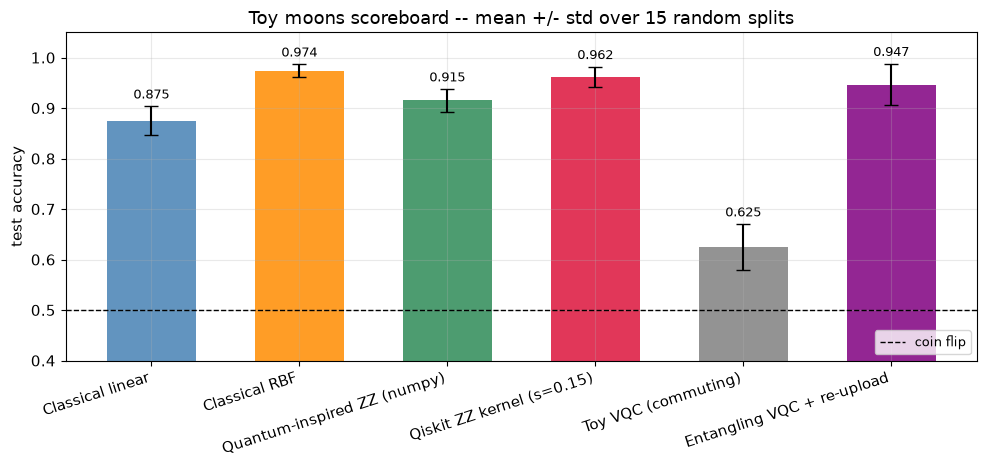

method                            mean     std     min     max   single split (sec. 5-11)
Classical linear                 0.875   0.028   0.830   0.940         0.860
Classical RBF                    0.974   0.013   0.950   1.000         0.990
Quantum-inspired ZZ (numpy)      0.915   0.022   0.860   0.960         0.910
Qiskit ZZ kernel (s=0.15)        0.962   0.020   0.920   0.990         0.980
Toy VQC (commuting)              0.625   0.045   0.560   0.730         0.750
Entangling VQC + re-upload       0.947   0.041   0.860   0.990         0.980


In [18]:
N_SPLITS = 15
methods = ['Classical linear', 'Classical RBF', 'Quantum-inspired ZZ (numpy)',
           f'Qiskit ZZ kernel (s={BEST_SCALE:.2f})', 'Toy VQC (commuting)',
           'Entangling VQC + re-upload']
scores = {m: [] for m in methods}

t0 = perf_counter()
for split in range(N_SPLITS):
    perm = np.random.default_rng(1000 + split).permutation(len(y))
    tr, te = perm[:n_train], perm[n_train:]
    Xtr_s, Xte_s, _, _ = standardize(X[tr], X[te])
    ytr, yte = y[tr], y[te]

    w, b, _ = fit_logistic(Xtr_s, ytr)
    scores[methods[0]].append((predict_logistic(Xte_s, w, b) == yte).mean())

    a = kernel_ridge_fit(rbf_kernel(Xtr_s, Xtr_s, gamma=gamma_rbf), ytr)
    scores[methods[1]].append(((rbf_kernel(Xte_s, Xtr_s, gamma=gamma_rbf) @ a > 0).astype(int) == yte).mean())

    a = kernel_ridge_fit(quantum_kernel(Xtr_s, Xtr_s, scale=scale_q), ytr)
    scores[methods[2]].append(((quantum_kernel(Xte_s, Xtr_s, scale=scale_q) @ a > 0).astype(int) == yte).mean())

    Ptr, Pte = qiskit_features(Xtr_s, BEST_SCALE), qiskit_features(Xte_s, BEST_SCALE)
    a = kernel_ridge_fit(fidelity_kernel(Ptr, Ptr), ytr)
    scores[methods[3]].append(((fidelity_kernel(Pte, Ptr) @ a > 0).astype(int) == yte).mean())

    ts = grid_sum[np.argmax([(((np.cos(Xtr_s[:, 0] + Xtr_s[:, 1] + t) > 0).astype(int)) == ytr).mean()
                             for t in grid_sum])]
    scores[methods[4]].append((((np.cos(Xte_s[:, 0] + Xte_s[:, 1] + ts) > 0).astype(int)) == yte).mean())

    p_ent, _ = train_entangling_vqc(Xtr_s, ytr, restarts=2, seed=50 + split)
    scores[methods[5]].append(((entangling_scores(Xte_s, p_ent) > 0).astype(int) == yte).mean())

means = np.array([np.mean(scores[m]) for m in methods])
stds = np.array([np.std(scores[m]) for m in methods])
print(f'{N_SPLITS} random splits in {perf_counter() - t0:.1f}s\n')

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'gray', 'purple']
ax.bar(np.arange(len(methods)), means, 0.6, yerr=stds, capsize=5, color=colors, alpha=0.85)
ax.set_xticks(np.arange(len(methods)))
ax.set_xticklabels(methods, rotation=18, ha='right')
ax.axhline(0.5, color='k', ls='--', lw=1, label='coin flip')
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('test accuracy')
ax.set_title(f'Toy moons scoreboard -- mean +/- std over {N_SPLITS} random splits')
ax.legend(loc='lower right', fontsize=9)
for i, (m_, s_) in enumerate(zip(means, stds)):
    ax.text(i, m_ + s_ + 0.015, f'{m_:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'{"method":<30}{"mean":>8}{"std":>8}{"min":>8}{"max":>8}   single split (sec. 5-11)')
single = [acc_log_te, acc_rbf_te, acc_q_te, acc_qkb_te, acc_v_te, acc_ent_te]
for m, one in zip(methods, single):
    v = np.array(scores[m])
    print(f'{m:<30}{v.mean():>8.3f}{v.std():>8.3f}{v.min():>8.3f}{v.max():>8.3f}{one:>14.3f}')

### Why the error bars matter

The single-split numbers reported throughout the notebook move by several points once
the split is resampled -- for some methods the spread is larger than the gap between
"quantum" and classical. Any ranking read off a single split of 320 points is noise.

With error bars the picture is stable and unexciting, which is the correct result: the
tuned classical kernel and the tuned quantum kernel land within one standard deviation
of each other, the commuting toy VQC sits well below both, and the entangling VQC
closes part of the gap at a much higher training cost.

### Mental picture to keep

```text
                 LEARNING FROM DATA
                         |
       +----------------+----------------+
       |                |                |
       v                v                v
  CLASSICAL          HYBRID           QUANTUM (alg.)
  mature models      VQC / QNN        kernels / HHL / AE
  CPU-GPU            circuit+opt      asymptotic stories
       |                |                |
       +--------+-------+--------+-------+
                |
                v
        Ask three questions:
        1) Is there a complexity reason to expect advantage?
        2) Does it survive data loading + noise?
        3) Does it beat a strong classical baseline?
```

### Thesis-ready sentences

1. QML is not one algorithm -- separate **classical**, **hybrid**, and **algorithmic quantum** claims.
2. A **quantum-inspired** kernel is a *different model* from the circuit it imitates:
   here the two Gram matrices disagree substantially, so results do not transfer.
3. Quantum-kernel generalisation is governed by the **encoding bandwidth**. Untuned, the
   same circuit ranges from coin-flip to competitive; exponential concentration towards
   $2^{-n}$ is already visible with 2 qubits.
4. The **cost** side is quadratic in the dataset: tens of thousands of circuits and hours
   of QPU time for a 320-point toy that a laptop solves in under a second.
5. Check the **algebra of the ansatz**: the classic one-qubit VQC has commuting
   generators and reduces to $\cos(x_1+x_2+\theta)$, a linear model in disguise.
6. Barren plateaus are **measured** here, and the global/local split matters: the
   $Z^{\otimes n}$ cost decays roughly like $2^{-n}$ while $Z_0Z_1$ stays trainable.
7. Report **mean +/- std over repeated splits**: on 320 points, single-split gaps between
   classical and quantum kernels are within the noise.
8. The cleanest *complexity* bridge to the finance notebooks in this folder remains
   **Amplitude Estimation** ($1/\varepsilon$ vs $1/\varepsilon^2$), not shallow classifiers.

### Ideas to explore next

- Swap moons for a tiny credit-scoring table (PD features) and repeat the scoreboard.
- Replace the exact fidelity kernel with `FidelityQuantumKernel` on a noisy backend and
  see how much of the bandwidth sweep survives readout error.
- Add kernel-target alignment as a model-selection criterion instead of test accuracy.
- Push the barren-plateau measurement to 12+ qubits with a tensor-network simulator.
- Link to `L0_05_rebentrost_qml_2014` and L2C fraud-QGNN tutorials in `tesi/papers/`.
